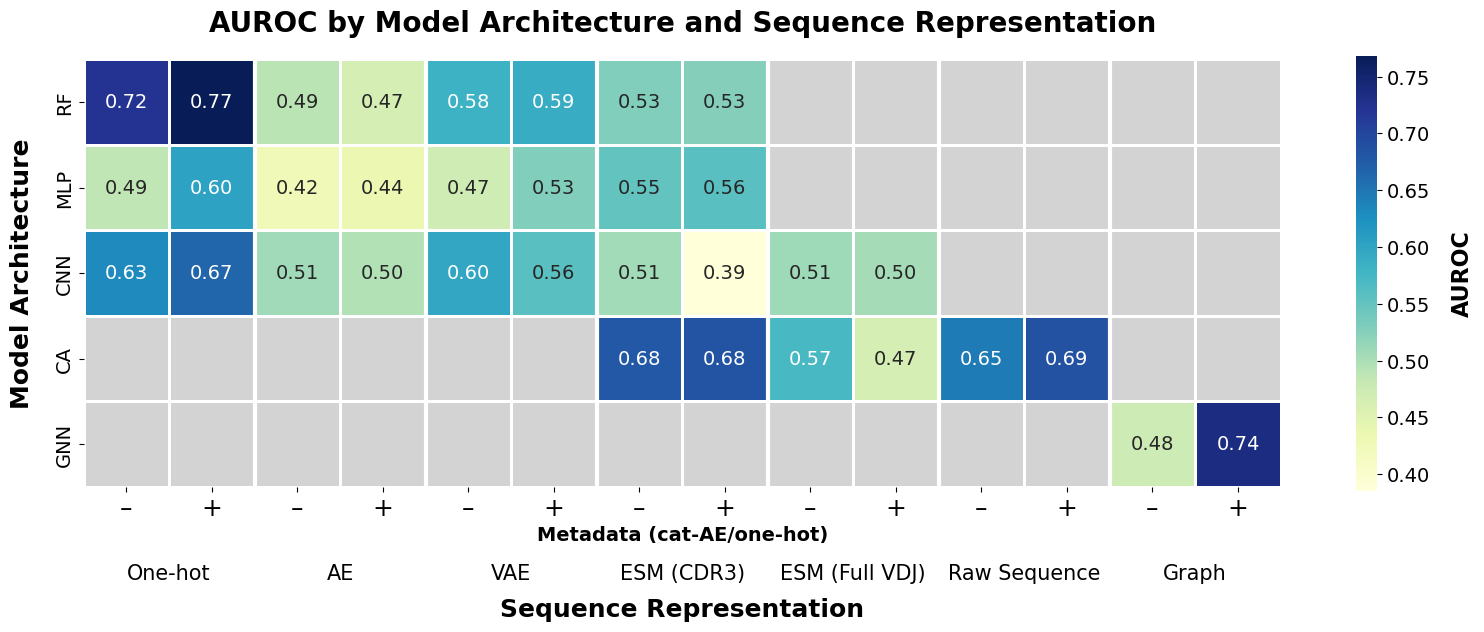

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv(r'outputs\models\all_results_summary.csv')

# 2. Clean and Extract Labels
def get_representation(name):
    name = name.lower()
    if 'esm_cdr3' in name or 'esm-cdr3' in name: return 'ESM (CDR3)'
    if 'esm_full' in name or 'esm-full' in name: return 'ESM (Full VDJ)'
    if 'vae' in name: return 'VAE'
    if 'one_hot' in name or 'onehot' in name: return 'One-hot'
    if 'raw' in name: return 'Raw Sequence'
    if 'gnn' in name: return 'Graph'
    if 'autoencoder' in name or 'ae' in name.split('_'): return 'AE'
    return 'Unknown'

def get_metadata_flag(row):
    vals = [str(row.get('metadata')), str(row.get('feature_augment')), str(row.get('categorical'))]
    for v in vals:
        if 'cat_ae' in v or 'one_hot' in v:
            return '+'
    if 'meta' in str(row['experiment_name']):
        return '+'
    return '–'

df['Representation'] = df['experiment_name'].apply(get_representation)
df['Metadata'] = df.apply(get_metadata_flag, axis=1)
df['Model'] = df['model'].replace({'cnn': 'CNN', 'cross_attention': 'CA', 'gnn': 'GNN', 'mlp': 'MLP', 'random_forest': 'RF'})

# 3. Define the Grid Ordering
rep_order = ['One-hot', 'AE', 'VAE', 'ESM (CDR3)', 'ESM (Full VDJ)', 'Raw Sequence', 'Graph']
model_order = ['RF', 'MLP', 'CNN', 'CA', 'GNN']

# 4. Create the Pivot Table
pivot_df = df.pivot_table(index='Model', columns=['Representation', 'Metadata'], values='auroc', aggfunc='max')

cols = pd.MultiIndex.from_product([rep_order, ['–', '+']], names=['Representation', 'Metadata'])
pivot_df = pivot_df.reindex(index=model_order, columns=cols)

# 5. Plotting
# Added an extra inch to the height to give the bottom margin more room
fig, ax = plt.subplots(figsize=(16, 9)) 

ax.set_facecolor('#d3d3d3')

sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="YlGnBu", 
            linewidths=1, linecolor='white', 
            annot_kws={"size": 14}, cbar_kws={"shrink": 0.5},
            cbar=True, ax=ax,
            mask=pivot_df.isna(), square=True)

# 6. Format Colorbar 
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label('AUROC', size=16, weight='bold', labelpad=15)

# 7. Format Y-Axis 
ax.set_ylabel('Model Architecture', fontsize=18, fontweight='bold', labelpad=15)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14, fontweight='normal')

# 8. Format X-Axis 
x_labels = [metadata for rep, metadata in pivot_df.columns]
ax.set_xticks(np.arange(len(x_labels)) + 0.5)
ax.set_xticklabels(x_labels, fontsize=18, fontweight='normal', rotation=0)

# Clear the default xlabel so it doesn't fight the manual text placements
ax.set_xlabel('')

# LEVEL 1: The Metadata Subtitle
# Adjust the '+ 0.3' to shift this string closer to or further from the +/- ticks
ax.text(len(pivot_df.columns) / 2, len(model_order) + 0.45, 
        'Metadata (cat-AE/one-hot)', 
        ha='center', va='top', fontsize=14, fontweight='bold')

# LEVEL 2: The Individual Representation Labels
for i, rep in enumerate(rep_order):
    x_center = (i * 2) + 1 
    # Adjust the '+ 0.7' to shift the representation names (One-hot, AE, etc.)
    y_pos = len(model_order) + 0.9
    ax.text(x_center, y_pos, rep, ha='center', va='top', fontsize=15, fontweight='normal')

# LEVEL 3: The Main Sequence Representation Title
# Adjust the '+ 1.1' to shift the overarching bottom title up or down
ax.text(len(pivot_df.columns) / 2, len(model_order) + 1.3, 
        'Sequence Representation', 
        ha='center', va='top', fontsize=18, fontweight='bold')

# Draw vertical divider lines
for i in range(1, len(rep_order)):
    ax.axvline(x=i*2, color='white', linewidth=3)

# 9. Format Main Title
plt.title('AUROC by Model Architecture and Sequence Representation', fontsize=20, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

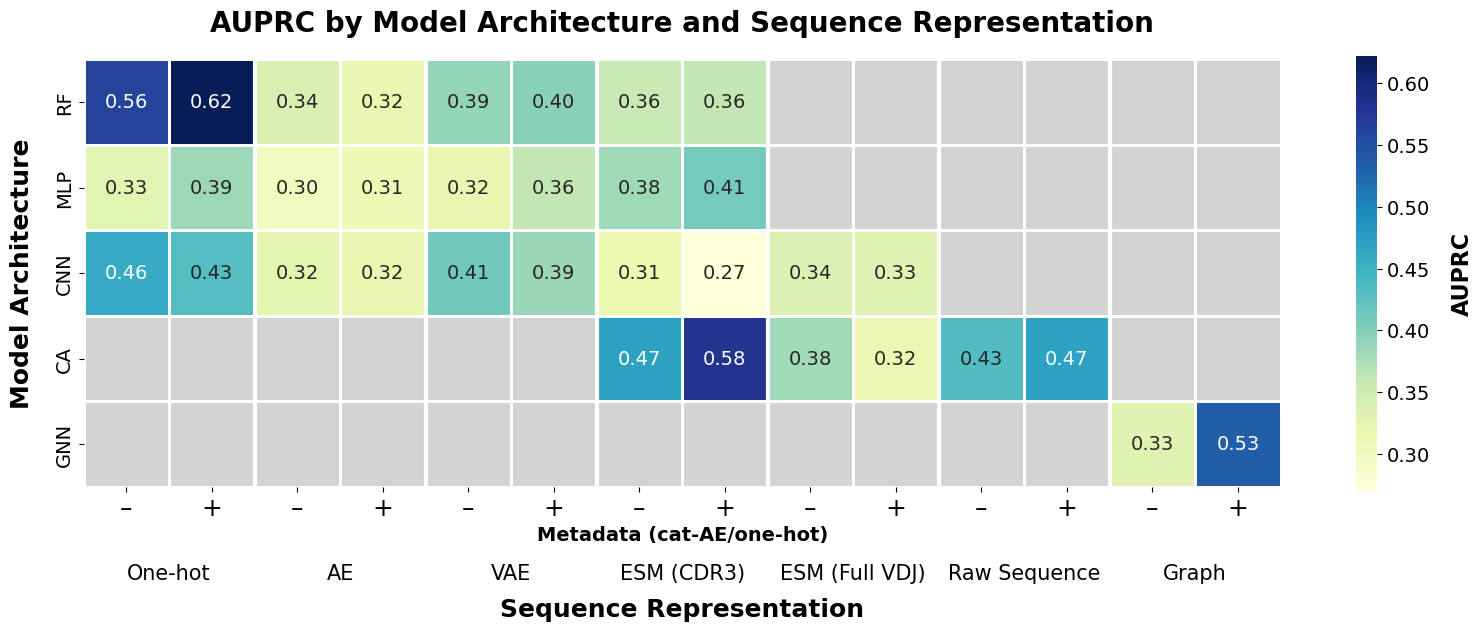

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv(r'outputs\models\all_results_summary.csv')

# 2. Clean and Extract Labels
def get_representation(name):
    name = name.lower()
    if 'esm_cdr3' in name or 'esm-cdr3' in name: return 'ESM (CDR3)'
    if 'esm_full' in name or 'esm-full' in name: return 'ESM (Full VDJ)'
    if 'vae' in name: return 'VAE'
    if 'one_hot' in name or 'onehot' in name: return 'One-hot'
    if 'raw' in name: return 'Raw Sequence'
    if 'gnn' in name: return 'Graph'
    if 'autoencoder' in name or 'ae' in name.split('_'): return 'AE'
    return 'Unknown'

def get_metadata_flag(row):
    vals = [str(row.get('metadata')), str(row.get('feature_augment')), str(row.get('categorical'))]
    for v in vals:
        if 'cat_ae' in v or 'one_hot' in v:
            return '+'
    if 'meta' in str(row['experiment_name']):
        return '+'
    return '–'

df['Representation'] = df['experiment_name'].apply(get_representation)
df['Metadata'] = df.apply(get_metadata_flag, axis=1)
df['Model'] = df['model'].replace({'cnn': 'CNN', 'cross_attention': 'CA', 'gnn': 'GNN', 'mlp': 'MLP', 'random_forest': 'RF'})

# 3. Define the Grid Ordering
rep_order = ['One-hot', 'AE', 'VAE', 'ESM (CDR3)', 'ESM (Full VDJ)', 'Raw Sequence', 'Graph']
model_order = ['RF', 'MLP', 'CNN', 'CA', 'GNN']

# 4. Create the Pivot Table
pivot_df = df.pivot_table(index='Model', columns=['Representation', 'Metadata'], values='auprc', aggfunc='max')

cols = pd.MultiIndex.from_product([rep_order, ['–', '+']], names=['Representation', 'Metadata'])
pivot_df = pivot_df.reindex(index=model_order, columns=cols)

# 5. Plotting
# Added an extra inch to the height to give the bottom margin more room
fig, ax = plt.subplots(figsize=(16, 9)) 

ax.set_facecolor('#d3d3d3')

sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="YlGnBu", 
            linewidths=1, linecolor='white', 
            annot_kws={"size": 14}, cbar_kws={"shrink": 0.5},
            cbar=True, ax=ax,
            mask=pivot_df.isna(), square=True)

# 6. Format Colorbar 
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label('AUPRC', size=16, weight='bold', labelpad=15)

# 7. Format Y-Axis 
ax.set_ylabel('Model Architecture', fontsize=18, fontweight='bold', labelpad=15)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14, fontweight='normal')

# 8. Format X-Axis 
x_labels = [metadata for rep, metadata in pivot_df.columns]
ax.set_xticks(np.arange(len(x_labels)) + 0.5)
ax.set_xticklabels(x_labels, fontsize=18, fontweight='normal', rotation=0)

# Clear the default xlabel so it doesn't fight the manual text placements
ax.set_xlabel('')

# LEVEL 1: The Metadata Subtitle
# Adjust the '+ 0.3' to shift this string closer to or further from the +/- ticks
ax.text(len(pivot_df.columns) / 2, len(model_order) + 0.45, 
        'Metadata (cat-AE/one-hot)', 
        ha='center', va='top', fontsize=14, fontweight='bold')

# LEVEL 2: The Individual Representation Labels
for i, rep in enumerate(rep_order):
    x_center = (i * 2) + 1 
    # Adjust the '+ 0.7' to shift the representation names (One-hot, AE, etc.)
    y_pos = len(model_order) + 0.9
    ax.text(x_center, y_pos, rep, ha='center', va='top', fontsize=15, fontweight='normal')

# LEVEL 3: The Main Sequence Representation Title
# Adjust the '+ 1.1' to shift the overarching bottom title up or down
ax.text(len(pivot_df.columns) / 2, len(model_order) + 1.3, 
        'Sequence Representation', 
        ha='center', va='top', fontsize=18, fontweight='bold')

# Draw vertical divider lines
for i in range(1, len(rep_order)):
    ax.axvline(x=i*2, color='white', linewidth=3)

# 9. Format Main Title
plt.title('AUPRC by Model Architecture and Sequence Representation', fontsize=20, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()